In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from IPython.display import display
from tqdm.auto import tqdm

from tokenizer import DigitTokenizer
from data_stream import MultiplicationDataStream
from lattice_multiplication_transformer import (
    LatticeMultiplicationTransformer,
)

In [2]:
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

batch_size = 100
max_seq_len = 32

d_model = 256
dropout = 0.1

learning_rate = 1e-4
weight_decay = 0.1

cell_loss_weight = 0.5
carry_loss_weight = 0.5

validation_interval = 100
validation_steps = 20
plot_interval = 10

use_bf16 = (
    device.type == "cuda"
    and torch.cuda.is_bf16_supported()
)

torch.set_float32_matmul_precision(
    "high"
)

print("Device:", device)
print("BF16:", use_bf16)

Device: cuda
BF16: True


In [3]:
tokenizer = DigitTokenizer()

data_stream = MultiplicationDataStream(
    tokenizer=tokenizer,
    batch_size=batch_size,
    max_seq_len=max_seq_len,
    initial_max=20,
    growth_rate=0.0,
    beta_alpha=2.0,
    beta_beta=5.0,
    max_operand_multiple=3,
    seed=42,
)

pad_id = tokenizer.char_to_int["<pad>"]
eos_id = tokenizer.char_to_int["<eos>"]

In [4]:
model = LatticeMultiplicationTransformer(
    vocab_size=tokenizer.vocab_size,
    max_seq_len=max_seq_len,
    pad_id=pad_id,
    eos_id=eos_id,
    d_model=d_model,
    dropout=dropout,
).to(device)

parameter_count = sum(
    parameter.numel()
    for parameter in model.parameters()
)

print(
    f"Parameters: {parameter_count:,}"
)

print(
    "Product sequence length:",
    model.product_seq_len,
)

print(
    "Carry vocabulary size:",
    model.carry_vocab_size,
)

Parameters: 1,373,797
Product sequence length: 65
Carry vocabulary size: 577


In [5]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=learning_rate,
    weight_decay=weight_decay,
)

product_loss_function = nn.CrossEntropyLoss(
    ignore_index=pad_id
)

cell_loss_function = nn.CrossEntropyLoss(
    ignore_index=-100
)

carry_loss_function = nn.CrossEntropyLoss(
    ignore_index=-100
)

In [6]:
def create_product_targets(
    a: torch.Tensor,
    b: torch.Tensor,
) -> torch.Tensor:
    product_targets = []

    for sample_a, sample_b in zip(
        a,
        b,
    ):
        a_digits = sample_a[
            sample_a != pad_id
        ].tolist()

        b_digits = sample_b[
            sample_b != pad_id
        ].tolist()

        a_value = sum(
            digit * 10**position
            for position, digit in enumerate(
                a_digits
            )
        )

        b_value = sum(
            digit * 10**position
            for position, digit in enumerate(
                b_digits
            )
        )

        product_value = (
            a_value
            * b_value
        )

        product_digits = [
            int(digit)
            for digit in reversed(
                str(product_value)
            )
        ]

        product_digits.append(
            eos_id
        )

        if (
            len(product_digits)
            > model.product_seq_len
        ):
            raise ValueError(
                f"Product requires {len(product_digits)} tokens, "
                f"but model supports {model.product_seq_len}."
            )

        product_digits += [
            pad_id
        ] * (
            model.product_seq_len
            - len(product_digits)
        )

        product_targets.append(
            product_digits
        )

    return torch.tensor(
        product_targets,
        dtype=torch.long,
        device=a.device,
    )

In [7]:
def create_cell_targets(
    a: torch.Tensor,
    b: torch.Tensor,
) -> tuple[
    torch.Tensor,
    torch.Tensor,
]:
    digit_products = (
        a.unsqueeze(2)
        * b.unsqueeze(1)
    )

    valid_cells = (
        (a != pad_id).unsqueeze(2)
        & (b != pad_id).unsqueeze(1)
    )

    ones_targets = (
        digit_products % 10
    )

    tens_targets = (
        digit_products // 10
    )

    ones_targets = ones_targets.masked_fill(
        ~valid_cells,
        -100,
    )

    tens_targets = tens_targets.masked_fill(
        ~valid_cells,
        -100,
    )

    return (
        ones_targets,
        tens_targets,
    )

In [8]:
def create_carry_targets(
    a: torch.Tensor,
    b: torch.Tensor,
) -> torch.Tensor:
    batch_size = a.shape[0]

    carry_targets = torch.full(
        (
            batch_size,
            model.product_seq_len,
        ),
        -100,
        dtype=torch.long,
        device=a.device,
    )

    for batch_index in range(
        batch_size
    ):
        a_digits = a[batch_index][
            a[batch_index] != pad_id
        ].tolist()

        b_digits = b[batch_index][
            b[batch_index] != pad_id
        ].tolist()

        product_value = (
            sum(
                digit * 10**position
                for position, digit in enumerate(
                    a_digits
                )
            )
            * sum(
                digit * 10**position
                for position, digit in enumerate(
                    b_digits
                )
            )
        )

        product_digit_count = len(
            str(product_value)
        )

        carry = 0

        for output_position in range(
            product_digit_count
        ):
            diagonal_sum = 0

            for i, digit_a in enumerate(
                a_digits
            ):
                for j, digit_b in enumerate(
                    b_digits
                ):
                    cell_product = (
                        digit_a
                        * digit_b
                    )

                    ones_digit = (
                        cell_product % 10
                    )

                    tens_digit = (
                        cell_product // 10
                    )

                    if (
                        i + j
                        == output_position
                    ):
                        diagonal_sum += (
                            ones_digit
                        )

                    if (
                        i + j + 1
                        == output_position
                    ):
                        diagonal_sum += (
                            tens_digit
                        )

            total = (
                diagonal_sum
                + carry
            )

            carry = (
                total // 10
            )

            carry_targets[
                batch_index,
                output_position,
            ] = carry

    return carry_targets

In [9]:
def truncate_predictions_after_eos(
    predictions: torch.Tensor,
) -> torch.Tensor:
    _, seq_len = predictions.shape

    positions = torch.arange(
        seq_len,
        device=predictions.device,
    ).unsqueeze(0)

    eos_mask = (
        predictions == eos_id
    )

    has_eos = eos_mask.any(
        dim=1
    )

    eos_positions = eos_mask.int().argmax(
        dim=1
    )

    after_eos = (
        positions
        > eos_positions.unsqueeze(1)
    )

    after_eos = (
        after_eos
        & has_eos.unsqueeze(1)
    )

    return predictions.masked_fill(
        after_eos,
        pad_id,
    )


def compute_exact_accuracy(
    predictions: torch.Tensor,
    targets: torch.Tensor,
) -> tuple[int, int]:
    predictions = (
        truncate_predictions_after_eos(
            predictions
        )
    )

    correct_tokens = (
        (predictions == targets)
        | (targets == pad_id)
    )

    correct_sequences = (
        correct_tokens.all(
            dim=1
        )
    )

    return (
        correct_sequences.sum().item(),
        targets.shape[0],
    )


def compute_masked_accuracy(
    logits: torch.Tensor,
    targets: torch.Tensor,
    ignore_index: int,
) -> tuple[int, int]:
    predictions = logits.argmax(
        dim=-1
    )

    valid_positions = (
        targets != ignore_index
    )

    correct_count = (
        (
            (predictions == targets)
            & valid_positions
        )
        .sum()
        .item()
    )

    valid_count = (
        valid_positions.sum().item()
    )

    return (
        correct_count,
        valid_count,
    )

def compute_product_token_accuracy(
    logits: torch.Tensor,
    targets: torch.Tensor,
) -> tuple[int, int]:
    predictions = logits.argmax(
        dim=-1
    )

    valid_positions = (
        targets != pad_id
    )

    correct_count = (
        (
            (predictions == targets)
            & valid_positions
        )
        .sum()
        .item()
    )

    token_count = (
        valid_positions.sum().item()
    )

    return (
        correct_count,
        token_count,
    )

In [10]:
@torch.no_grad()
def validate_model() -> dict[str, float]:
    model.eval()

    validation_loader = (
        data_stream.create_validation_chunk_loader(
            num_steps=validation_steps,
            lookahead_steps=0,
            batch_size=batch_size,
            seed=10_000,
        )
    )

    total_loss_sum = 0.0
    product_loss_sum = 0.0
    ones_loss_sum = 0.0
    tens_loss_sum = 0.0
    carry_loss_sum = 0.0

    product_correct = 0
    product_count = 0

    product_token_correct = 0
    product_token_count = 0

    ones_correct = 0
    ones_count = 0

    tens_correct = 0
    tens_count = 0

    carry_correct = 0
    carry_count = 0

    total_batches = 0

    for batch in validation_loader:
        batch = batch.to(
            device
        )

        a, b, _, _ = batch.unbind(
            dim=1
        )

        product_targets = (
            create_product_targets(
                a,
                b,
            )
        )

        (
            ones_targets,
            tens_targets,
        ) = create_cell_targets(
            a,
            b,
        )

        carry_targets = (
            create_carry_targets(
                a,
                b,
            )
        )

        with torch.autocast(
            device_type=device.type,
            dtype=torch.bfloat16,
            enabled=use_bf16,
        ):
            (
                product_logits,
                ones_cell_logits,
                tens_cell_logits,
                carry_logits,
            ) = model(
                a,
                b,
            )

            product_loss = (
                product_loss_function(
                    product_logits.reshape(
                        -1,
                        tokenizer.vocab_size,
                    ),
                    product_targets.reshape(
                        -1
                    ),
                )
            )

            ones_loss = (
                cell_loss_function(
                    ones_cell_logits.reshape(
                        -1,
                        10,
                    ),
                    ones_targets.reshape(
                        -1
                    ),
                )
            )

            tens_loss = (
                cell_loss_function(
                    tens_cell_logits.reshape(
                        -1,
                        10,
                    ),
                    tens_targets.reshape(
                        -1
                    ),
                )
            )

            carry_loss = (
                carry_loss_function(
                    carry_logits.reshape(
                        -1,
                        model.carry_vocab_size,
                    ),
                    carry_targets.reshape(
                        -1
                    ),
                )
            )

            total_loss = (
                product_loss
                + cell_loss_weight * ones_loss
                + cell_loss_weight * tens_loss
                + carry_loss_weight * carry_loss
            )

        product_predictions = (
            product_logits.argmax(
                dim=-1
            )
        )

        (
            batch_product_correct,
            batch_product_count,
        ) = compute_exact_accuracy(
            product_predictions,
            product_targets,
        )

        (
            batch_product_token_correct,
            batch_product_token_count,
        ) = compute_product_token_accuracy(
            product_logits,
            product_targets,
        )

        (
            batch_ones_correct,
            batch_ones_count,
        ) = compute_masked_accuracy(
            ones_cell_logits,
            ones_targets,
            -100,
        )

        (
            batch_tens_correct,
            batch_tens_count,
        ) = compute_masked_accuracy(
            tens_cell_logits,
            tens_targets,
            -100,
        )

        (
            batch_carry_correct,
            batch_carry_count,
        ) = compute_masked_accuracy(
            carry_logits,
            carry_targets,
            -100,
        )

        product_correct += (
            batch_product_correct
        )

        product_count += (
            batch_product_count
        )

        product_token_correct += (
            batch_product_token_correct
        )

        product_token_count += (
            batch_product_token_count
        )

        ones_correct += (
            batch_ones_correct
        )

        ones_count += (
            batch_ones_count
        )

        tens_correct += (
            batch_tens_correct
        )

        tens_count += (
            batch_tens_count
        )

        carry_correct += (
            batch_carry_correct
        )

        carry_count += (
            batch_carry_count
        )

        total_loss_sum += (
            total_loss.item()
        )

        product_loss_sum += (
            product_loss.item()
        )

        ones_loss_sum += (
            ones_loss.item()
        )

        tens_loss_sum += (
            tens_loss.item()
        )

        carry_loss_sum += (
            carry_loss.item()
        )

        total_batches += 1

    return {
        "total_loss": (
            total_loss_sum
            / total_batches
        ),
        "product_loss": (
            product_loss_sum
            / total_batches
        ),
        "ones_loss": (
            ones_loss_sum
            / total_batches
        ),
        "tens_loss": (
            tens_loss_sum
            / total_batches
        ),
        "carry_loss": (
            carry_loss_sum
            / total_batches
        ),
        "product_accuracy": (
            product_correct
            / product_count
        ),
        "product_token_accuracy": (
            product_token_correct
            / product_token_count
        ),
        "ones_accuracy": (
            ones_correct
            / ones_count
        ),
        "tens_accuracy": (
            tens_correct
            / tens_count
        ),
        "carry_accuracy": (
            carry_correct
            / carry_count
        ),
    }

In [11]:
global_step = 0

train_step_history = []

train_total_loss_history = []
train_product_loss_history = []
train_carry_loss_history = []

train_product_accuracy_history = []
train_product_token_accuracy_history = []
train_ones_accuracy_history = []
train_tens_accuracy_history = []
train_carry_accuracy_history = []

validation_step_history = []

validation_total_loss_history = []
validation_product_loss_history = []
validation_carry_loss_history = []

validation_product_accuracy_history = []
validation_product_token_accuracy_history = []
validation_ones_accuracy_history = []
validation_tens_accuracy_history = []
validation_carry_accuracy_history = []

In [12]:
def train_model(
    steps: int,
) -> None:
    global global_step

    figure, axes = plt.subplots(
        3,
        1,
        figsize=(14, 14),
        sharex=True,
    )

    total_loss_axis = axes[0]
    component_loss_axis = axes[1]
    accuracy_axis = axes[2]

    display_handle = display(
        figure,
        display_id=True,
    )

    def update_live_plot() -> None:
        total_loss_axis.clear()
        component_loss_axis.clear()
        accuracy_axis.clear()

        total_loss_axis.plot(
            train_step_history,
            train_total_loss_history,
            label="Training total loss",
            linewidth=2,
        )

        if validation_total_loss_history:
            total_loss_axis.plot(
                validation_step_history,
                validation_total_loss_history,
                label="Validation total loss",
                linewidth=2,
                marker="o",
            )

        component_loss_axis.plot(
            train_step_history,
            train_product_loss_history,
            label="Training product loss",
            linewidth=2,
        )

        component_loss_axis.plot(
            train_step_history,
            train_carry_loss_history,
            label="Training carry loss",
            linewidth=2,
        )

        if validation_product_loss_history:
            component_loss_axis.plot(
                validation_step_history,
                validation_product_loss_history,
                label="Validation product loss",
                linewidth=2,
                marker="o",
            )

            component_loss_axis.plot(
                validation_step_history,
                validation_carry_loss_history,
                label="Validation carry loss",
                linewidth=2,
                marker="o",
            )

        accuracy_axis.plot(
            train_step_history,
            train_product_accuracy_history,
            label="Training exact product accuracy",
            linewidth=2,
        )

        accuracy_axis.plot(
            train_step_history,
            train_product_token_accuracy_history,
            label="Training product token accuracy",
            linewidth=2,
        )

        accuracy_axis.plot(
            train_step_history,
            train_carry_accuracy_history,
            label="Training carry accuracy",
            linewidth=2,
        )

        accuracy_axis.plot(
            train_step_history,
            train_ones_accuracy_history,
            label="Training ones-cell accuracy",
            linewidth=1.5,
        )

        accuracy_axis.plot(
            train_step_history,
            train_tens_accuracy_history,
            label="Training tens-cell accuracy",
            linewidth=1.5,
        )

        if validation_product_accuracy_history:
            accuracy_axis.plot(
                validation_step_history,
                validation_product_accuracy_history,
                label="Validation exact product accuracy",
                linewidth=2,
                marker="o",
            )

            accuracy_axis.plot(
                validation_step_history,
                validation_product_token_accuracy_history,
                label="Validation product token accuracy",
                linewidth=2,
                marker="o",
            )

            accuracy_axis.plot(
                validation_step_history,
                validation_carry_accuracy_history,
                label="Validation carry accuracy",
                linewidth=2,
                marker="o",
            )

            accuracy_axis.plot(
                validation_step_history,
                validation_ones_accuracy_history,
                label="Validation ones-cell accuracy",
                linewidth=1.5,
                marker="o",
            )

            accuracy_axis.plot(
                validation_step_history,
                validation_tens_accuracy_history,
                label="Validation tens-cell accuracy",
                linewidth=1.5,
                marker="o",
            )

        total_loss_axis.set_title(
            "Lattice Multiplication With Carry Supervision"
        )

        total_loss_axis.set_ylabel(
            "Total loss"
        )

        component_loss_axis.set_ylabel(
            "Component loss"
        )

        accuracy_axis.set_xlabel(
            "Training step"
        )

        accuracy_axis.set_ylabel(
            "Accuracy"
        )

        accuracy_axis.set_ylim(
            0.0,
            1.0,
        )

        total_loss_axis.legend(
            loc="upper right"
        )

        component_loss_axis.legend(
            loc="upper right"
        )

        accuracy_axis.legend(
            loc="lower right"
        )

        total_loss_axis.grid(
            alpha=0.3
        )

        component_loss_axis.grid(
            alpha=0.3
        )

        accuracy_axis.grid(
            alpha=0.3
        )

        figure.tight_layout()

        display_handle.update(
            figure
        )

    progress_bar = tqdm(
        range(steps),
        desc="Training multiplication",
    )

    for _ in progress_bar:
        model.train()

        batch = data_stream.next_batch().to(
            device
        )

        a, b, _, _ = batch.unbind(
            dim=1
        )

        product_targets = (
            create_product_targets(
                a,
                b,
            )
        )

        (
            ones_targets,
            tens_targets,
        ) = create_cell_targets(
            a,
            b,
        )

        carry_targets = (
            create_carry_targets(
                a,
                b,
            )
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        with torch.autocast(
            device_type=device.type,
            dtype=torch.bfloat16,
            enabled=use_bf16,
        ):
            (
                product_logits,
                ones_cell_logits,
                tens_cell_logits,
                carry_logits,
            ) = model(
                a,
                b,
            )

            product_loss = (
                product_loss_function(
                    product_logits.reshape(
                        -1,
                        tokenizer.vocab_size,
                    ),
                    product_targets.reshape(
                        -1
                    ),
                )
            )

            ones_loss = (
                cell_loss_function(
                    ones_cell_logits.reshape(
                        -1,
                        10,
                    ),
                    ones_targets.reshape(
                        -1
                    ),
                )
            )

            tens_loss = (
                cell_loss_function(
                    tens_cell_logits.reshape(
                        -1,
                        10,
                    ),
                    tens_targets.reshape(
                        -1
                    ),
                )
            )

            carry_loss = (
                carry_loss_function(
                    carry_logits.reshape(
                        -1,
                        model.carry_vocab_size,
                    ),
                    carry_targets.reshape(
                        -1
                    ),
                )
            )

            total_loss = (
                product_loss
                + cell_loss_weight * ones_loss
                + cell_loss_weight * tens_loss
                + carry_loss_weight * carry_loss
            )

        total_loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0,
        )

        optimizer.step()

        with torch.no_grad():
            product_predictions = (
                product_logits.argmax(
                    dim=-1
                )
            )

            (
                product_correct,
                product_count,
            ) = compute_exact_accuracy(
                product_predictions,
                product_targets,
            )

            (
                product_token_correct,
                product_token_count,
            ) = compute_product_token_accuracy(
                product_logits,
                product_targets,
            )

            (
                ones_correct,
                ones_count,
            ) = compute_masked_accuracy(
                ones_cell_logits,
                ones_targets,
                -100,
            )

            (
                tens_correct,
                tens_count,
            ) = compute_masked_accuracy(
                tens_cell_logits,
                tens_targets,
                -100,
            )

            (
                carry_correct,
                carry_count,
            ) = compute_masked_accuracy(
                carry_logits,
                carry_targets,
                -100,
            )

            product_accuracy = (
                product_correct
                / product_count
            )

            product_token_accuracy = (
                product_token_correct
                / product_token_count
            )

            ones_accuracy = (
                ones_correct
                / ones_count
            )

            tens_accuracy = (
                tens_correct
                / tens_count
            )

            carry_accuracy = (
                carry_correct
                / carry_count
            )

        global_step += 1

        train_step_history.append(
            global_step
        )

        train_total_loss_history.append(
            total_loss.item()
        )

        train_product_loss_history.append(
            product_loss.item()
        )

        train_carry_loss_history.append(
            carry_loss.item()
        )

        train_product_accuracy_history.append(
            product_accuracy
        )

        train_product_token_accuracy_history.append(
            product_token_accuracy
        )

        train_ones_accuracy_history.append(
            ones_accuracy
        )

        train_tens_accuracy_history.append(
            tens_accuracy
        )

        train_carry_accuracy_history.append(
            carry_accuracy
        )

        if (
            global_step
            % validation_interval
            == 0
        ):
            validation_results = (
                validate_model()
            )

            validation_step_history.append(
                global_step
            )

            validation_total_loss_history.append(
                validation_results[
                    "total_loss"
                ]
            )

            validation_product_loss_history.append(
                validation_results[
                    "product_loss"
                ]
            )

            validation_carry_loss_history.append(
                validation_results[
                    "carry_loss"
                ]
            )

            validation_product_accuracy_history.append(
                validation_results[
                    "product_accuracy"
                ]
            )

            validation_product_token_accuracy_history.append(
                validation_results[
                    "product_token_accuracy"
                ]
            )

            validation_ones_accuracy_history.append(
                validation_results[
                    "ones_accuracy"
                ]
            )

            validation_tens_accuracy_history.append(
                validation_results[
                    "tens_accuracy"
                ]
            )

            validation_carry_accuracy_history.append(
                validation_results[
                    "carry_accuracy"
                ]
            )

        if (
            global_step
            % plot_interval
            == 0
        ):
            update_live_plot()

        progress_values = {
            "step": global_step,
            "total_loss": (
                f"{total_loss.item():.4f}"
            ),
            "product_loss": (
                f"{product_loss.item():.4f}"
            ),
            "carry_loss": (
                f"{carry_loss.item():.4f}"
            ),
            "product_acc": (
                f"{product_accuracy:.4f}"
            ),
            "product_token_acc": (
                f"{product_token_accuracy:.4f}"
            ),
            "carry_acc": (
                f"{carry_accuracy:.4f}"
            ),
            "ones_acc": (
                f"{ones_accuracy:.4f}"
            ),
            "tens_acc": (
                f"{tens_accuracy:.4f}"
            ),
        }

        if validation_product_accuracy_history:
            progress_values[
                "val_product_acc"
            ] = (
                f"{validation_product_accuracy_history[-1]:.4f}"
            )

            progress_values[
                "val_product_token_acc"
            ] = (
                f"{validation_product_token_accuracy_history[-1]:.4f}"
            )

            progress_values[
                "val_carry_acc"
            ] = (
                f"{validation_carry_accuracy_history[-1]:.4f}"
            )

        progress_bar.set_postfix(
            progress_values
        )

    update_live_plot()

    plt.close(
        figure
    )

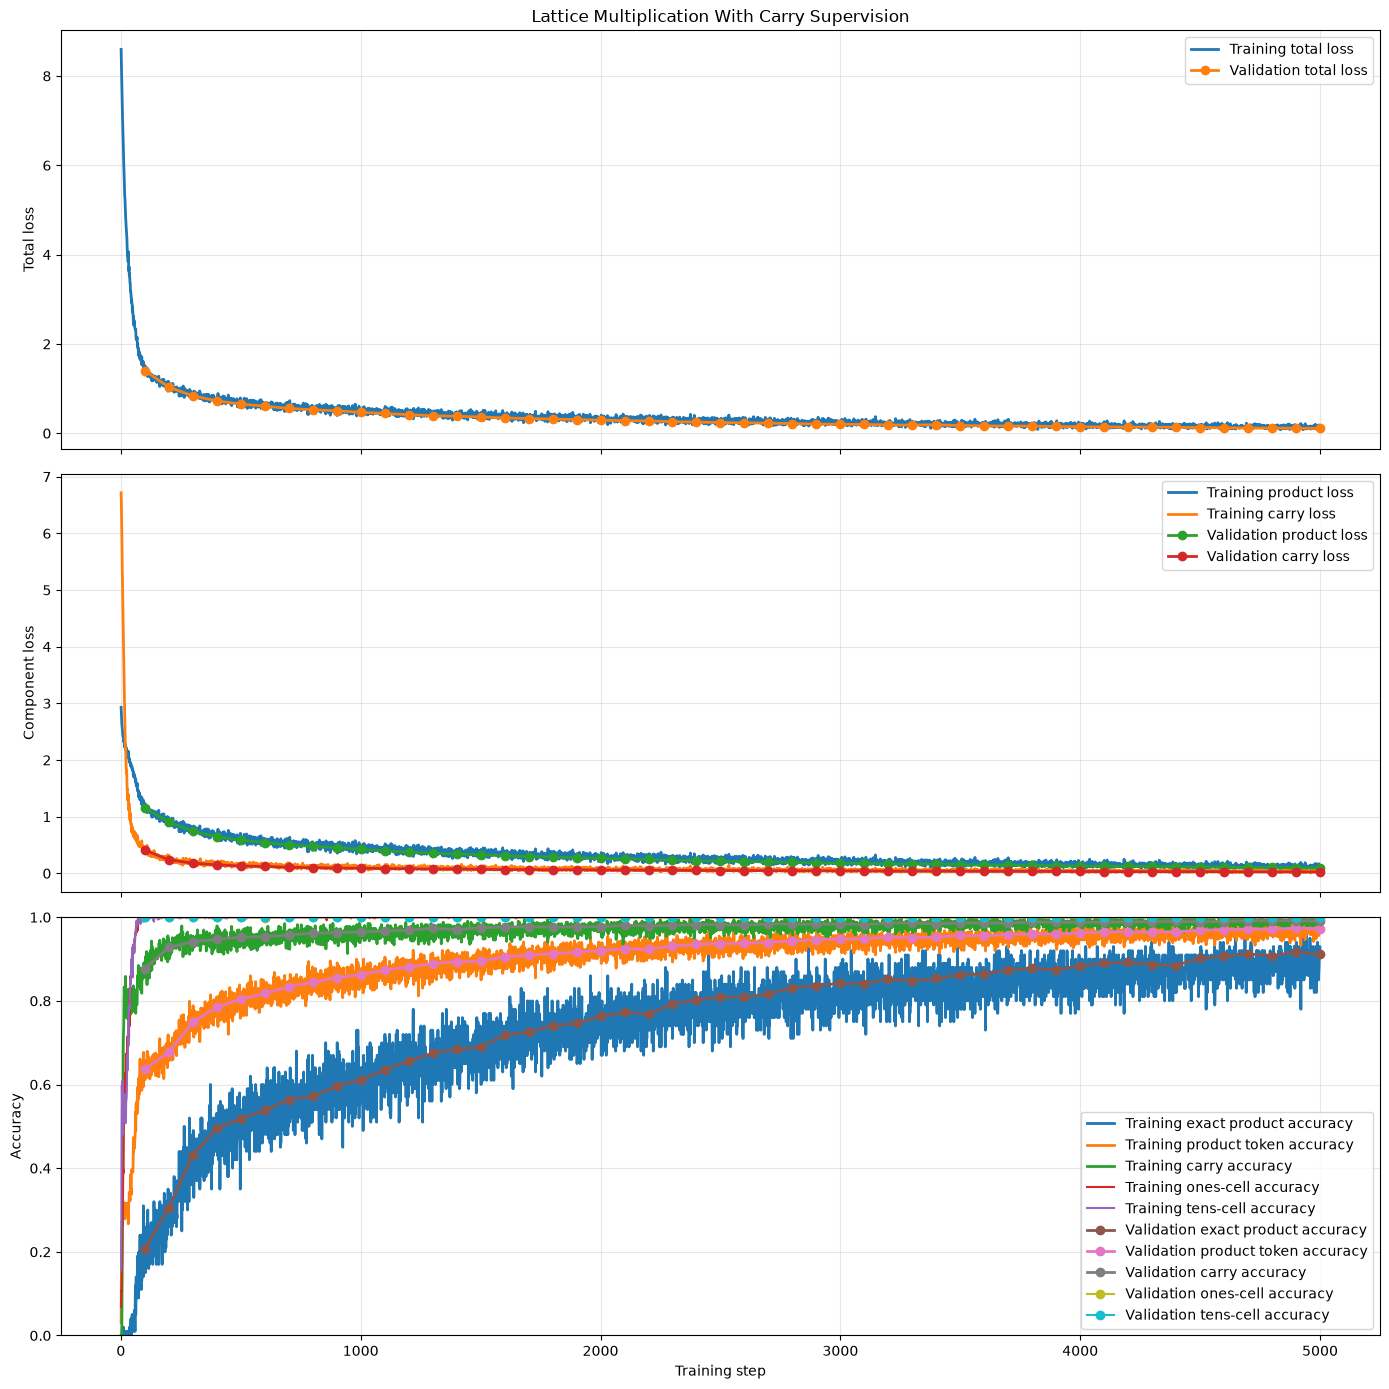

Training multiplication:   0%|          | 0/3000 [00:00<?, ?it/s]

In [ ]:
train_model(
    steps=3_000,
)

In [14]:
@torch.no_grad()
def show_failed_predictions(
    num_examples: int = 20,
) -> None:
    model.eval()

    batch = data_stream.next_batch().to(
        device
    )

    a, b, _, _ = batch.unbind(
        dim=1
    )

    targets = create_product_targets(
        a,
        b,
    )

    predictions = model.predict(
        a,
        b,
    )

    shown = 0

    for index in range(batch.shape[0]):
        target_tokens = targets[index][
            targets[index] != pad_id
        ].tolist()

        prediction_tokens = predictions[index][
            predictions[index] != pad_id
        ].tolist()

        if prediction_tokens == target_tokens:
            continue

        a_digits = a[index][
            a[index] != pad_id
        ].tolist()

        b_digits = b[index][
            b[index] != pad_id
        ].tolist()

        a_value = sum(
            digit * 10**position
            for position, digit in enumerate(
                a_digits
            )
        )

        b_value = sum(
            digit * 10**position
            for position, digit in enumerate(
                b_digits
            )
        )

        target_text = tokenizer.decode(
            target_tokens
        )

        prediction_text = tokenizer.decode(
            prediction_tokens
        )

        print(
            f"{a_value} × {b_value} = {a_value * b_value}"
        )

        print(
            "target reversed:    ",
            target_text,
        )

        print(
            "prediction reversed:",
            prediction_text,
        )

        print()

        shown += 1

        if shown >= num_examples:
            break

In [15]:
show_failed_predictions()

131 × 247 = 32357
target reversed:     75323
prediction reversed: 75113

23 × 165 = 3795
target reversed:     5973
prediction reversed: 5963

90 × 166 = 14940
target reversed:     04941
prediction reversed: 04951

64 × 185 = 11840
target reversed:     04811
prediction reversed: 04311

223 × 112 = 24976
target reversed:     67942
prediction reversed: 67722

159 × 197 = 31323
target reversed:     32313
prediction reversed: 32352

31 × 75 = 2325
target reversed:     5232
prediction reversed: 5222

76 × 79 = 6004
target reversed:     4006
prediction reversed: 4045

121 × 217 = 26257
target reversed:     75262
prediction reversed: 75352

48 × 12 = 576
target reversed:     675
prediction reversed: 695

47 × 63 = 2961
target reversed:     1692
prediction reversed: 1452

17 × 31 = 527
target reversed:     725
prediction reversed: 715

0 × 15 = 0
target reversed:     0
prediction reversed: 00

173 × 171 = 29583
target reversed:     38592
prediction reversed: 38482

19 × 27 = 513
target reversed